/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-newb4145 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


HEAT EXCHANGER DESIGN - KERN METHOD

Heat Duty Q: 4436.80 kW
LMTD: 78.93 K
Correction Factor Ft: 1.000
Effective Temperature Difference: 78.93 K
Tube Length L: 4.88 m
Number of Passes: 2

VELOCITY CONSTRAINTS (Section 12.7.2):
  Tube-side (high-pressure vapour): 5.0-10.0 m/s
  Shell-side: condensing HPS; velocity and ΔP estimated with homogeneous two-phase model

DESIGN RESULTS FOR DIFFERENT TUBE DIAMETERS
d_o(m)   d_i(m)   A(m²)    N_t    D_s(m)   h_t        h_s        U          ΔPt      ΔPs      V-OK  
                                           W/m²K      W/m²K      W/m²K      kPa      kPa            
--------------------------------------------------------------------------------
0.016    0.012    45.9     188    0.392    5762.5     6028.3     1224.8     710.68   7.392     ✗    
0.020    0.016    50.8     166    0.451    3792.8     5917.9     1105.5     237.92   3.284     ✗    
0.025    0.021    58.8     154    0.530    2468.6     5771.7     955.8      79.06    1.335     ✗    
0.03

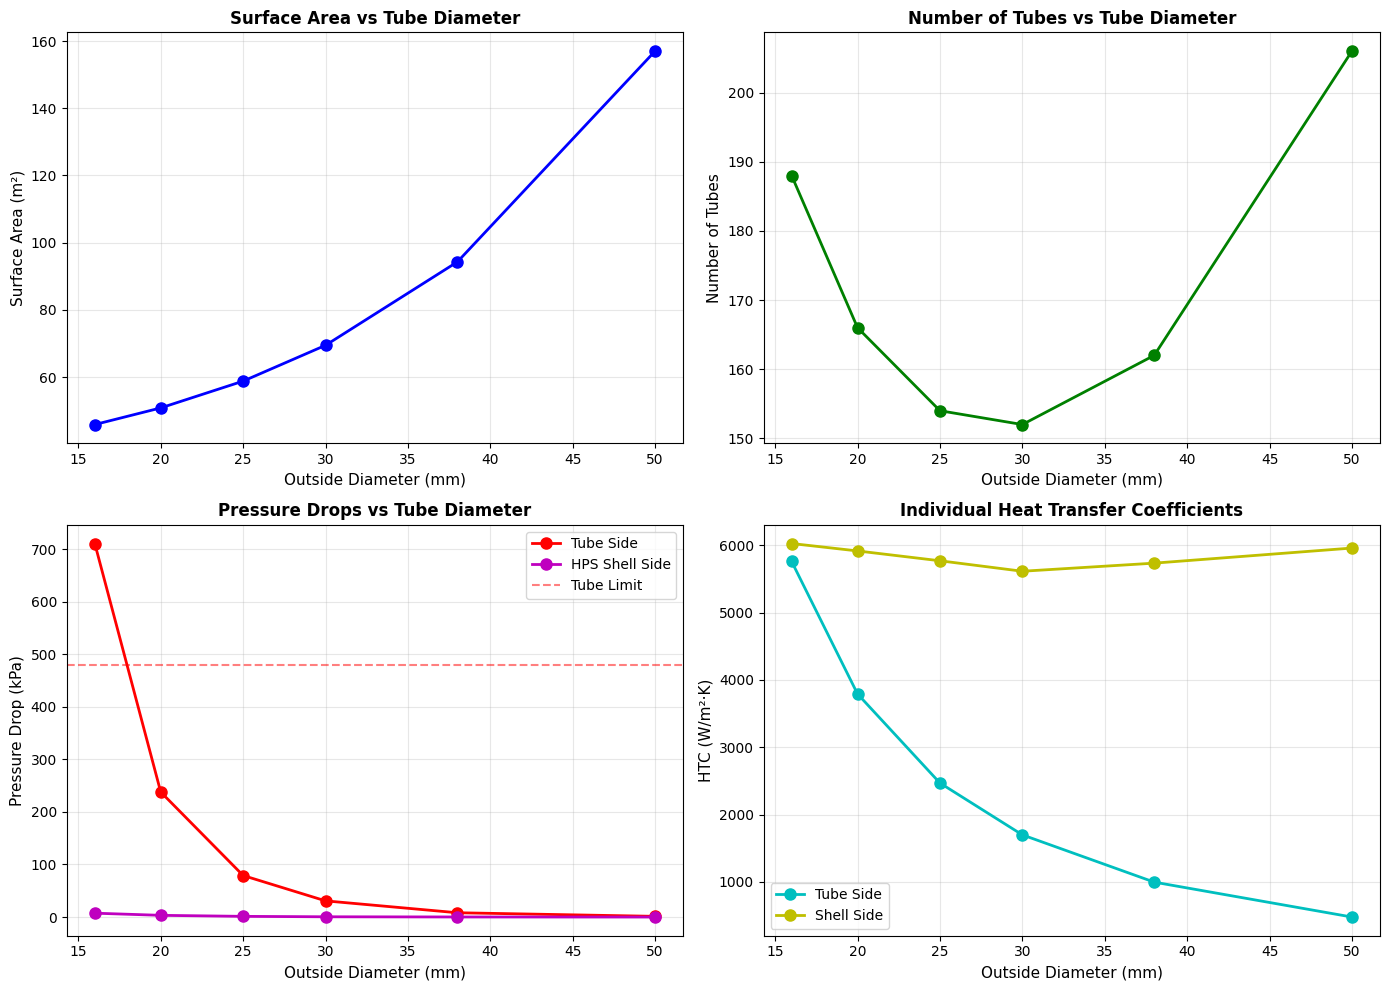


ACCEPTABLE DESIGNS (Meeting ALL Criteria):

Tube OD: 38.0 mm
  Number of tubes: 162
  Shell diameter: 805.3 mm
  Overall U: 596.1 W/m²·K
  Tube velocity: 9.11 m/s (Target: 5.0-10.0 m/s)
  HPS inlet vapour velocity: 1.766 m/s
  Condensate outlet velocity: 0.0719 m/s
  Tube pressure drop: 8.21 kPa (Max: 479 kPa)
  HPS shell pressure drop: 0.161 kPa
    friction contribution: 0.254 kPa
    acceleration/recovery contribution: -0.092 kPa

DETAILED VELOCITY ANALYSIS:

Tube OD: 16.0 mm
  Reynolds Number (Tube): 432250 (Turbulent)
  Reynolds Number (HPS vapour inlet): 127183
  Mean homogeneous two-phase Reynolds number: 77314
  Velocity (Tube): 63.02 m/s ✗ (Target: 5.0-10.0 m/s)
  HPS vapour inlet velocity: 7.446 m/s
  Condensate outlet velocity: 0.3032 m/s
  Pressure Drop: Tube=710.68 kPa, HPS shell=7.392 kPa
  Overall Assessment: NOT ACCEPTABLE

Tube OD: 20.0 mm
  Reynolds Number (Tube): 367152 (Turbulent)
  Reynolds Number (HPS vapour inlet): 120405
  Mean homogeneous two-phase Reynolds nu

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Implements Kern method for shell and tube heat exchanger design

# =============================================================================
# INPUT PARAMETERS
# =============================================================================

# shell side
m_h = 4436.8/1571.0      # Condensing steam mass flow rate, kg/s
Cp_h = 0                    # Not used for condensing steam
rho_h = 757.0               # Saturated condensate density at ~6 MPa, kg/m³
mu_h = 9.5e-5               # Saturated condensate viscosity, Pa·s
k_h = 0.59                  # Condensate thermal conductivity, W/m·K
rho_v_h = 30.82             # Saturated HPS vapour density at ~6 MPa, kg/m³
mu_v_h = 2.05e-5            # Saturated HPS vapour viscosity, Pa·s
hfg_h = 1571.0e3            # Latent heat of condensation, J/kg
fouling_h = 0.0001          # Fouling factor, m²·K/W
T1 = 275.6                  # HPS saturation temperature, °C
T2 = 275.6                  # HPS condenses approximately isothermally, °C

# tube side
mass_flow_kg_h = {'H2': 3783.344, 'N2': 455.726, 'CO': 15809.452, 'CO2': 4703.471, 'CH4': 7887.074, 'H2O': 1.265, 'C2H2': 78.953, 'C2H4': 1316.273, 'C2H6': 5.568, 'C6H6': 0.509, 'CH3OH': 423.206}
Cp_values = {'H2': 14.5, 'N2': 1.05, 'CO': 1.05, 'CO2': 0.98, 'CH4': 2.69, 'H2O': 1.93, 'C2H2': 2.02, 'C2H4': 2.05, 'C2H6': 2.37, 'C6H6': 1.61, 'CH3OH': 1.73, 'H2S': 1.05}
MW_values = {'H2': 2.01588, 'N2': 28.0134, 'CO': 28.0101, 'CO2': 44.0095, 'CH4': 16.0425, 'H2O': 18.01528, 'C2H2': 26.0373, 'C2H4': 28.0532, 'C2H6': 30.069, 'C6H6': 78.1118, 'CH3OH': 32.04186, 'H2S': 34.0809}

m_c = sum(mass_flow_kg_h.values())/3600
Cp_c = (
    sum(mass_flow_kg_h[i] * Cp_values[i] for i in mass_flow_kg_h)
    / sum(mass_flow_kg_h.values())
) * 1000

total_kmol_h = sum(
    mass_flow_kg_h[i] / MW_values[i]
    for i in mass_flow_kg_h
)

MW_mix = sum(mass_flow_kg_h.values()) / total_kmol_h

t1 = 96.4
t2 = 250.0

T_mean_K = ((t1 + t2)/2) + 273.15
P_Pa = 48.96 * 1e5
Z = 1.02

rho_c = P_Pa * (MW_mix/1000) / (Z * 8.314462618 * T_mean_K)
mu_c = 2.5e-05
k_c = 0.12
fouling_c = 0.0002

# Tube specifications
d_o_list = [0.016, 0.020, 0.025, 0.030, 0.038, 0.050]
wall_thickness = 0.002
k_w = 45.0
L = 4.88
pitch_ratio = 1.25
N_p = 2

# Design parameters
U_assumed = 500
baffle_spacing_ratio = 0.4

# Kern/Sinnott gas correlation
heating_or_cooling = 0.33

# Allowable pressure drops
system_gauge_pressure_bar = 48.96 - 1.01325
deltaP_tube_max = 0.10 * system_gauge_pressure_bar * 1e5
deltaP_shell_max = float("nan")

# Velocity constraints
v_tube_min = 5.0
v_tube_max = 10.0
v_shell_min = float("nan")
v_shell_max = float("nan")

# Design duty
Q_design = 4436.8 * 1000

# =============================================================================
# HEAT TRANSFER CALCULATIONS
# =============================================================================

def calculate_heat_duty():
    """Use Aspen duty as design basis"""
    return Q_design

def calculate_LMTD(T1, T2, t1, t2):
    """Calculate Log Mean Temperature Difference"""
    delta_T1 = T1 - t2
    delta_T2 = T2 - t1

    if abs(delta_T1 - delta_T2) < 1e-6:
        return delta_T1

    return abs(
        (delta_T1 - delta_T2)
        / math.log(abs(delta_T1) / abs(delta_T2))
    )

def calculate_Ft(T1, T2, t1, t2):
    """Condensing steam gives an effectively constant hot-side temperature"""
    return 1.0

# =============================================================================
# TUBE BUNDLE GEOMETRY
# =============================================================================

def calculate_tube_count(A_req, d_o, L):
    """Calculate number of tubes required"""
    N_t = A_req / (math.pi * d_o * L)
    N_t = int(math.ceil(N_t))

    remainder = N_t % N_p
    if remainder != 0:
        N_t += N_p - remainder

    return N_t

def calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p):
    """Calculate tube bundle diameter constants"""
    constants = {
        1: (0.319, 2.142),
        2: (0.249, 2.207),
        4: (0.175, 2.285),
        6: (0.0743, 2.499)
    }

    K1, n1 = constants.get(N_p, (0.249, 2.207))
    D_b = d_o * (N_t / K1) ** (1 / n1)
    return D_b

def calculate_shell_diameter(D_b):
    """Calculate shell diameter from bundle diameter"""
    if D_b < 0.3:
        clearance = 0.05
    elif D_b < 0.5:
        clearance = 0.07
    elif D_b < 1.0:
        clearance = 0.09
    else:
        clearance = 0.11

    return D_b + clearance

# =============================================================================
# TUBE SIDE CALCULATIONS
# =============================================================================

def tube_side_coefficient(d_i, N_t, N_p, m, rho, mu, k, Cp):
    """Calculate tube side heat transfer coefficient"""
    A_t = (N_t / N_p) * math.pi * d_i**2 / 4

    u_t = m / (rho * A_t)

    Re = rho * u_t * d_i / mu

    Pr = Cp * mu / k

    if Re > 2100:
        Nu = 0.021 * Re**0.8 * Pr**0.33
    else:
        Nu = 3.66

    h_t = Nu * k / d_i

    return h_t, Re, u_t

def tube_side_pressure_drop(N_p, L, d_i, rho, u_t, Re):
    """Calculate tube side pressure drop"""
    if Re > 2100:
        jf = 0.079 * Re**(-0.25)
    else:
        jf = 16 / Re

    deltaP = N_p * (8 * jf * (L / d_i) + 2.5) * (rho * u_t**2 / 2)

    return deltaP

# =============================================================================
# SHELL SIDE CALCULATIONS
# =============================================================================

def shell_side_equivalent_diameter(d_o, pitch_ratio):
    """Equivalent hydraulic diameter for a triangular tube layout."""
    p_t = pitch_ratio * d_o
    d_e = (1.10 / d_o) * (p_t**2 - 0.917 * d_o**2)
    return d_e

def shell_side_crossflow_area(D_s, d_o, l_B, pitch_ratio):
    """
    Kern-type minimum shell-side cross-flow area between baffles.

    A_s = D_s * B * (p_t - d_o) / p_t
    """
    p_t = pitch_ratio * d_o
    return D_s * l_B * (p_t - d_o) / p_t

def shell_side_coefficient(D_s, d_o, d_e, baffle_spacing_ratio,
                           m, rho, mu, k, Cp, A_inst):
    """
    Condensation heat-transfer coefficient for saturated HPS.

    The thermal calculation remains based on film condensation. Shell-side
    velocity and pressure drop are calculated separately using the two-phase
    homogeneous hydraulic model below.
    """
    D_b = max(D_s - 0.09, d_o)
    p_t = pitch_ratio * d_o
    vertical_rows = max(1, round(D_b / p_t))

    heat_flux = Q_design / A_inst
    film_delta_T = 8.0

    for _ in range(50):
        h_single = 0.725 * (
            (
                rho_h * (rho_h - rho_v_h) * 9.80665
                * hfg_h * k_h**3
            )
            / (
                mu_h * d_o * max(film_delta_T, 0.1)
            )
        )**0.25

        h_s = h_single / vertical_rows**0.25
        film_delta_T_new = heat_flux / h_s
        film_delta_T = 0.5 * film_delta_T + 0.5 * film_delta_T_new

    l_B = baffle_spacing_ratio * D_s

    # Hydraulic Reynolds number/velocity are calculated separately because
    # steam quality changes continuously during condensation.
    Re = float("nan")
    u_s = float("nan")

    return h_s, Re, u_s, l_B

def condensing_hps_hydraulics(D_s, d_o, d_e, L, l_B, m_dot,
                              rho_v, rho_l, mu_v, mu_l,
                              n_segments=200):
    """
    Estimate shell-side HPS velocity and pressure drop during condensation.

    Method:
      - Kern-type shell cross-flow area.
      - Saturated vapour enters at quality x = 1 and leaves as condensate x = 0.
      - Homogeneous two-phase density:
            1/rho_tp = x/rho_v + (1-x)/rho_l
      - Homogeneous mixture viscosity (reciprocal mixing rule):
            1/mu_tp = x/mu_v + (1-x)/mu_l
      - Darcy friction factor:
            f = 0.3164/Re^0.25  (turbulent)
        with f = 64/Re for laminar flow.
      - Friction is integrated over the effective shell-side cross-flow path.
      - The acceleration/condensation pressure-recovery term is included.

    This is a preliminary two-phase hydraulic estimate, not a detailed
    Bell-Delaware or commercial condenser-rating calculation.
    """
    A_s = shell_side_crossflow_area(D_s, d_o, l_B, pitch_ratio)
    if A_s <= 0:
        raise ValueError("Calculated shell-side flow area must be positive.")

    G = m_dot / A_s  # kg/m²/s

    # Superficial phase velocities at the limiting ends
    u_v_in = m_dot / (rho_v * A_s)
    u_l_out = m_dot / (rho_l * A_s)

    # Number of shell cross-flow sections and effective hydraulic flow length.
    # Kern shell-side pressure-drop treatment uses approximately one shell-
    # diameter cross-flow path per baffle compartment.
    n_cross = max(1, int(math.ceil(L / l_B)))
    L_eff = n_cross * D_s
    ds = L_eff / n_segments

    deltaP_f = 0.0
    Re_values = []

    for j in range(n_segments):
        # Midpoint quality, decreasing linearly from saturated vapour to liquid
        x = 1.0 - (j + 0.5) / n_segments

        rho_tp = 1.0 / (x / rho_v + (1.0 - x) / rho_l)
        mu_tp = 1.0 / (x / mu_v + (1.0 - x) / mu_l)

        Re_tp = G * d_e / mu_tp
        Re_values.append(Re_tp)

        if Re_tp > 4000:
            f_D = 0.3164 * Re_tp**(-0.25)
        elif Re_tp > 0:
            f_D = 64.0 / Re_tp
        else:
            f_D = 0.0

        deltaP_f += f_D * (ds / d_e) * (G**2 / (2.0 * rho_tp))

    # Momentum/acceleration term. During condensation this is normally negative
    # because the mixture becomes denser, giving partial pressure recovery.
    deltaP_acc = G**2 * (1.0 / rho_l - 1.0 / rho_v)

    deltaP_total = deltaP_f + deltaP_acc

    return {
        "A_s": A_s,
        "G": G,
        "u_v_in": u_v_in,
        "u_l_out": u_l_out,
        "Re_v_in": G * d_e / mu_v,
        "Re_l_out": G * d_e / mu_l,
        "Re_tp_mean": sum(Re_values) / len(Re_values),
        "deltaP_f": deltaP_f,
        "deltaP_acc": deltaP_acc,
        "deltaP_total": deltaP_total,
        "n_cross": n_cross,
        "L_eff": L_eff,
    }

def shell_side_pressure_drop(D_s, d_o, d_e, L, l_B):
    """Return the preliminary two-phase HPS hydraulic estimate."""
    return condensing_hps_hydraulics(
        D_s, d_o, d_e, L, l_B, m_h,
        rho_v_h, rho_h, mu_v_h, mu_h
    )

# =============================================================================
# OVERALL HEAT TRANSFER COEFFICIENT
# =============================================================================

def calculate_overall_U(h_t, h_s, d_o, d_i, k_w, fouling_t, fouling_s):
    """Calculate overall heat transfer coefficient"""
    U_inv = (
        1/h_s
        + fouling_s
        + d_o * math.log(d_o/d_i) / (2 * k_w)
        + (d_o * fouling_t) / d_i
        + d_o / (d_i * h_t)
    )

    return 1 / U_inv

# =============================================================================
# MAIN DESIGN ITERATION
# =============================================================================

Q = calculate_heat_duty()
LMTD = calculate_LMTD(T1, T2, t1, t2)
Ft = calculate_Ft(T1, T2, t1, t2)
deltaT_m = Ft * LMTD

print("="*80)
print("HEAT EXCHANGER DESIGN - KERN METHOD")
print("="*80)
print(f"\nHeat Duty Q: {Q/1000:.2f} kW")
print(f"LMTD: {LMTD:.2f} K")
print(f"Correction Factor Ft: {Ft:.3f}")
print(f"Effective Temperature Difference: {deltaT_m:.2f} K")
print(f"Tube Length L: {L} m")
print(f"Number of Passes: {N_p}")
print("\n" + "="*80)
print("VELOCITY CONSTRAINTS (Section 12.7.2):")
print(f"  Tube-side (high-pressure vapour): {v_tube_min}-{v_tube_max} m/s")
print("  Shell-side: condensing HPS; velocity and ΔP estimated with homogeneous two-phase model")
print("="*80)

results = []

for d_o in d_o_list:
    d_i = d_o - 2 * wall_thickness

    if d_i <= 0:
        print(f"Warning: Invalid tube inner diameter for d_o={d_o}. Skipping.")
        continue

    U_calc = U_assumed
    tolerance = 0.01
    max_iterations = 50

    for iteration in range(max_iterations):
        A_req = Q / (U_calc * deltaT_m)

        N_t = calculate_tube_count(A_req, d_o, L)

        D_b = calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p)
        D_s = calculate_shell_diameter(D_b)

        A_inst = N_t * math.pi * d_o * L

        h_t, Re_t, u_t = tube_side_coefficient(
            d_i, N_t, N_p, m_c, rho_c, mu_c, k_c, Cp_c
        )

        deltaP_t = tube_side_pressure_drop(
            N_p, L, d_i, rho_c, u_t, Re_t
        )

        d_e = shell_side_equivalent_diameter(d_o, pitch_ratio)

        h_s, Re_s, u_s, l_B = shell_side_coefficient(
            D_s, d_o, d_e, baffle_spacing_ratio,
            m_h, rho_h, mu_h, k_h, Cp_h, A_inst
        )

        hps_hyd = shell_side_pressure_drop(
            D_s, d_o, d_e, L, l_B
        )
        deltaP_s = hps_hyd["deltaP_total"]
        Re_s = hps_hyd["Re_v_in"]
        u_s = hps_hyd["u_v_in"]

        U_new = calculate_overall_U(
            h_t, h_s, d_o, d_i, k_w, fouling_c, fouling_h
        )

        if abs(U_new - U_calc) / U_calc < tolerance:
            U_calc = U_new
            break

        U_calc = U_new

    A_req = Q / (U_calc * deltaT_m)
    N_t = calculate_tube_count(A_req, d_o, L)
    D_b = calculate_bundle_diameter(N_t, d_o, pitch_ratio, N_p)
    D_s = calculate_shell_diameter(D_b)
    A_inst = N_t * math.pi * d_o * L

    h_t, Re_t, u_t = tube_side_coefficient(
        d_i, N_t, N_p, m_c, rho_c, mu_c, k_c, Cp_c
    )

    deltaP_t = tube_side_pressure_drop(
        N_p, L, d_i, rho_c, u_t, Re_t
    )

    h_s, Re_s, u_s, l_B = shell_side_coefficient(
        D_s, d_o, d_e, baffle_spacing_ratio,
        m_h, rho_h, mu_h, k_h, Cp_h, A_inst
    )

    hps_hyd = shell_side_pressure_drop(
        D_s, d_o, d_e, L, l_B
    )
    deltaP_s = hps_hyd["deltaP_total"]
    Re_s = hps_hyd["Re_v_in"]
    u_s = hps_hyd["u_v_in"]

    v_tube_ok = (v_tube_min <= u_t <= v_tube_max)
    velocity_ok = v_tube_ok

    L_over_D = L / D_s
    geometry_ok = 5.0 <= L_over_D <= 10.0
    pressure_ok = deltaP_t < deltaP_tube_max

    results.append({
        'd_o': d_o,
        'd_i': d_i,
        'A_req': A_req,
        'A_inst': A_inst,
        'N_t': N_t,
        'D_s': D_s,
        'h_t': h_t,
        'h_s': h_s,
        'U': U_calc,
        'deltaP_t': deltaP_t/1000,
        'deltaP_s': deltaP_s/1000 if not math.isnan(deltaP_s) else float("nan"),
        'Re_t': Re_t,
        'Re_s': Re_s,
        'u_t': u_t,
        'u_s': u_s,
        'u_hps_vap_in': hps_hyd['u_v_in'],
        'u_hps_cond_out': hps_hyd['u_l_out'],
        'Re_hps_vap_in': hps_hyd['Re_v_in'],
        'Re_hps_cond_out': hps_hyd['Re_l_out'],
        'Re_hps_tp_mean': hps_hyd['Re_tp_mean'],
        'G_hps': hps_hyd['G'],
        'A_shell_flow': hps_hyd['A_s'],
        'deltaP_hps_f': hps_hyd['deltaP_f']/1000,
        'deltaP_hps_acc': hps_hyd['deltaP_acc']/1000,
        'deltaP_hps_total': hps_hyd['deltaP_total']/1000,
        'v_tube_ok': v_tube_ok,
        'v_shell_ok': True,
        'velocity_ok': velocity_ok,
        'pressure_ok': pressure_ok,
        'geometry_ok': geometry_ok
    })

# Display results
print("\nDESIGN RESULTS FOR DIFFERENT TUBE DIAMETERS")
print("="*80)
print(f"{'d_o(m)':<8} {'d_i(m)':<8} {'A(m²)':<8} {'N_t':<6} {'D_s(m)':<8} "
      f"{'h_t':<10} {'h_s':<10} {'U':<10} {'ΔPt':<8} {'ΔPs':<8} {'V-OK':<6}")
print(f"{'':8} {'':8} {'':8} {'':6} {'':8} {'W/m²K':<10} {'W/m²K':<10} "
      f"{'W/m²K':<10} {'kPa':<8} {'kPa':<8} {'':6}")
print("-"*80)

for r in results:
    marker = " ✓" if r['velocity_ok'] else " ✗"
    shell_dp_text = f"{r['deltaP_hps_total']:.3f}"
    print(f"{r['d_o']:<8.3f} {r['d_i']:<8.3f} {r['A_req']:<8.1f} {r['N_t']:<6} "
          f"{r['D_s']:<8.3f} {r['h_t']:<10.1f} {r['h_s']:<10.1f} {r['U']:<10.1f} "
          f"{r['deltaP_t']:<8.2f} {shell_dp_text:<8} {marker:<6}")

# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

d_o_values = [r['d_o']*1000 for r in results]

ax1.plot(d_o_values, [r['A_req'] for r in results], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax1.set_ylabel('Surface Area (m²)', fontsize=11)
ax1.set_title('Surface Area vs Tube Diameter', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(d_o_values, [r['N_t'] for r in results], 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax2.set_ylabel('Number of Tubes', fontsize=11)
ax2.set_title('Number of Tubes vs Tube Diameter', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

ax3.plot(d_o_values, [r['deltaP_t'] for r in results], 'ro-', label='Tube Side', linewidth=2, markersize=8)
ax3.plot(d_o_values, [r['deltaP_hps_total'] for r in results], 'mo-', label='HPS Shell Side', linewidth=2, markersize=8)
ax3.axhline(y=deltaP_tube_max/1000, color='r', linestyle='--', alpha=0.5, label='Tube Limit')
ax3.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax3.set_ylabel('Pressure Drop (kPa)', fontsize=11)
ax3.set_title('Pressure Drops vs Tube Diameter', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.plot(d_o_values, [r['h_t'] for r in results], 'co-', label='Tube Side', linewidth=2, markersize=8)
ax4.plot(d_o_values, [r['h_s'] for r in results], 'yo-', label='Shell Side', linewidth=2, markersize=8)
ax4.set_xlabel('Outside Diameter (mm)', fontsize=11)
ax4.set_ylabel('HTC (W/m²·K)', fontsize=11)
ax4.set_title('Individual Heat Transfer Coefficients', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

acceptable_designs = [
    r for r in results
    if r['velocity_ok']
    and r['pressure_ok']
    and r['geometry_ok']
]

if acceptable_designs:
    print("\n" + "="*80)
    print("ACCEPTABLE DESIGNS (Meeting ALL Criteria):")
    print("="*80)

    for r in acceptable_designs:
        print(f"\nTube OD: {r['d_o']*1000:.1f} mm")
        print(f"  Number of tubes: {r['N_t']}")
        print(f"  Shell diameter: {r['D_s']*1000:.1f} mm")
        print(f"  Overall U: {r['U']:.1f} W/m²·K")
        print(f"  Tube velocity: {r['u_t']:.2f} m/s (Target: {v_tube_min}-{v_tube_max} m/s)")
        print(f"  HPS inlet vapour velocity: {r['u_hps_vap_in']:.3f} m/s")
        print(f"  Condensate outlet velocity: {r['u_hps_cond_out']:.4f} m/s")
        print(f"  Tube pressure drop: {r['deltaP_t']:.2f} kPa (Max: {deltaP_tube_max/1000:.0f} kPa)")
        print(f"  HPS shell pressure drop: {r['deltaP_hps_total']:.3f} kPa")
        print(f"    friction contribution: {r['deltaP_hps_f']:.3f} kPa")
        print(f"    acceleration/recovery contribution: {r['deltaP_hps_acc']:.3f} kPa")
else:
    print("\n" + "="*80)
    print("WARNING: No designs meet ALL criteria!")
    print("Consider:")
    print("  - Adjusting tube length")
    print("  - Changing number of tube passes")
    print("  - Using different tube diameters")
    print("="*80)

print("\n" + "="*80)
print("DETAILED VELOCITY ANALYSIS:")
print("="*80)

for i, r in enumerate(results):
    print(f"\nTube OD: {r['d_o']*1000:.1f} mm")
    print(f"  Reynolds Number (Tube): {r['Re_t']:.0f} "
          f"({'Turbulent' if r['Re_t'] > 4000 else 'Transitional' if r['Re_t'] > 2100 else 'Laminar'})")
    print(f"  Reynolds Number (HPS vapour inlet): {r['Re_hps_vap_in']:.0f}")
    print(f"  Mean homogeneous two-phase Reynolds number: {r['Re_hps_tp_mean']:.0f}")
    print(f"  Velocity (Tube): {r['u_t']:.2f} m/s {'✓' if r['v_tube_ok'] else '✗'} "
          f"(Target: {v_tube_min}-{v_tube_max} m/s)")
    print(f"  HPS vapour inlet velocity: {r['u_hps_vap_in']:.3f} m/s")
    print(f"  Condensate outlet velocity: {r['u_hps_cond_out']:.4f} m/s")
    print(f"  Pressure Drop: Tube={r['deltaP_t']:.2f} kPa, HPS shell={r['deltaP_hps_total']:.3f} kPa")
    print(f"  Overall Assessment: "
          f"{'ACCEPTABLE' if r['velocity_ok'] and r['pressure_ok'] and r['geometry_ok'] else 'NOT ACCEPTABLE'}")

if acceptable_designs:
    selected = acceptable_designs[0]
    print("\n" + "="*80)
    print("SELECTED DESIGN - HPS SHELL-SIDE HYDRAULIC ESTIMATE")
    print("="*80)
    print(f"Tube OD: {selected['d_o']*1000:.1f} mm")
    print(f"Shell-side minimum cross-flow area: {selected['A_shell_flow']:.5f} m²")
    print(f"HPS mass flux: {selected['G_hps']:.2f} kg/m².s")
    print(f"HPS inlet vapour velocity: {selected['u_hps_vap_in']:.3f} m/s")
    print(f"Condensate outlet velocity: {selected['u_hps_cond_out']:.4f} m/s")
    print(f"HPS inlet vapour Reynolds number: {selected['Re_hps_vap_in']:.0f}")
    print(f"Mean homogeneous two-phase Reynolds number: {selected['Re_hps_tp_mean']:.0f}")
    print(f"Frictional pressure drop: {selected['deltaP_hps_f']:.3f} kPa")
    print(f"Acceleration/condensation pressure recovery: {selected['deltaP_hps_acc']:.3f} kPa")
    print(f"Estimated total HPS shell-side pressure drop: {selected['deltaP_hps_total']:.3f} kPa")
    print("Note: this is a preliminary homogeneous two-phase estimate.")

print("\n" + "="*80)
print("DESIGN COMPLETE")
print("="*80)
